# Hypertension — Exploratory Data Analysis
Dataset: Framingham Heart Study.

**Important design choice:** this dataset's main target
column is `TenYearCHD` (10-year heart disease risk), but our
project needs a **hypertension** prediction. The dataset also
includes `prevalentHyp` — whether the patient currently has
hypertension — which is the column we'll actually predict.
We'll drop `TenYearCHD` since it's a different outcome and
could leak information about the patient's overall risk.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


## 1. Load the dataset

In [2]:
df = pd.read_csv("../../data/raw/hypertension.csv")
df.head()


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## 2. Basic info

In [3]:
print("Shape:", df.shape)
df.info()


Shape: (4240, 16)
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


## 3. Check for missing values
This dataset commonly has missing values in `education`,
`cigsPerDay`, `BPMeds`, `totChol`, `BMI`, `heartRate`, `glucose`.

In [4]:
df.isnull().sum()


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

## 4. Class balance — using prevalentHyp as our target

prevalentHyp
0    2923
1    1317
Name: count, dtype: int64


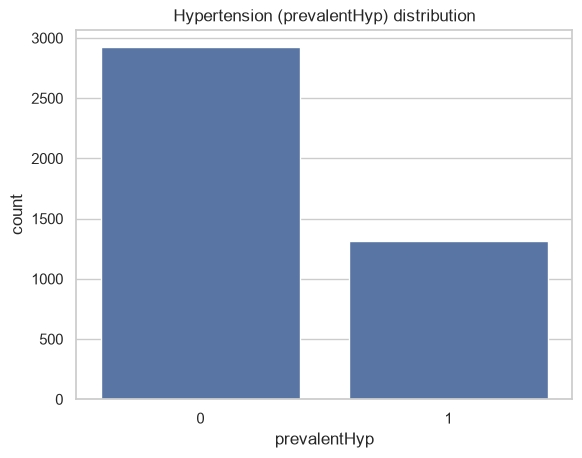

In [5]:
print(df["prevalentHyp"].value_counts())

sns.countplot(x="prevalentHyp", data=df)
plt.title("Hypertension (prevalentHyp) distribution")
plt.show()


## 5. Feature distributions

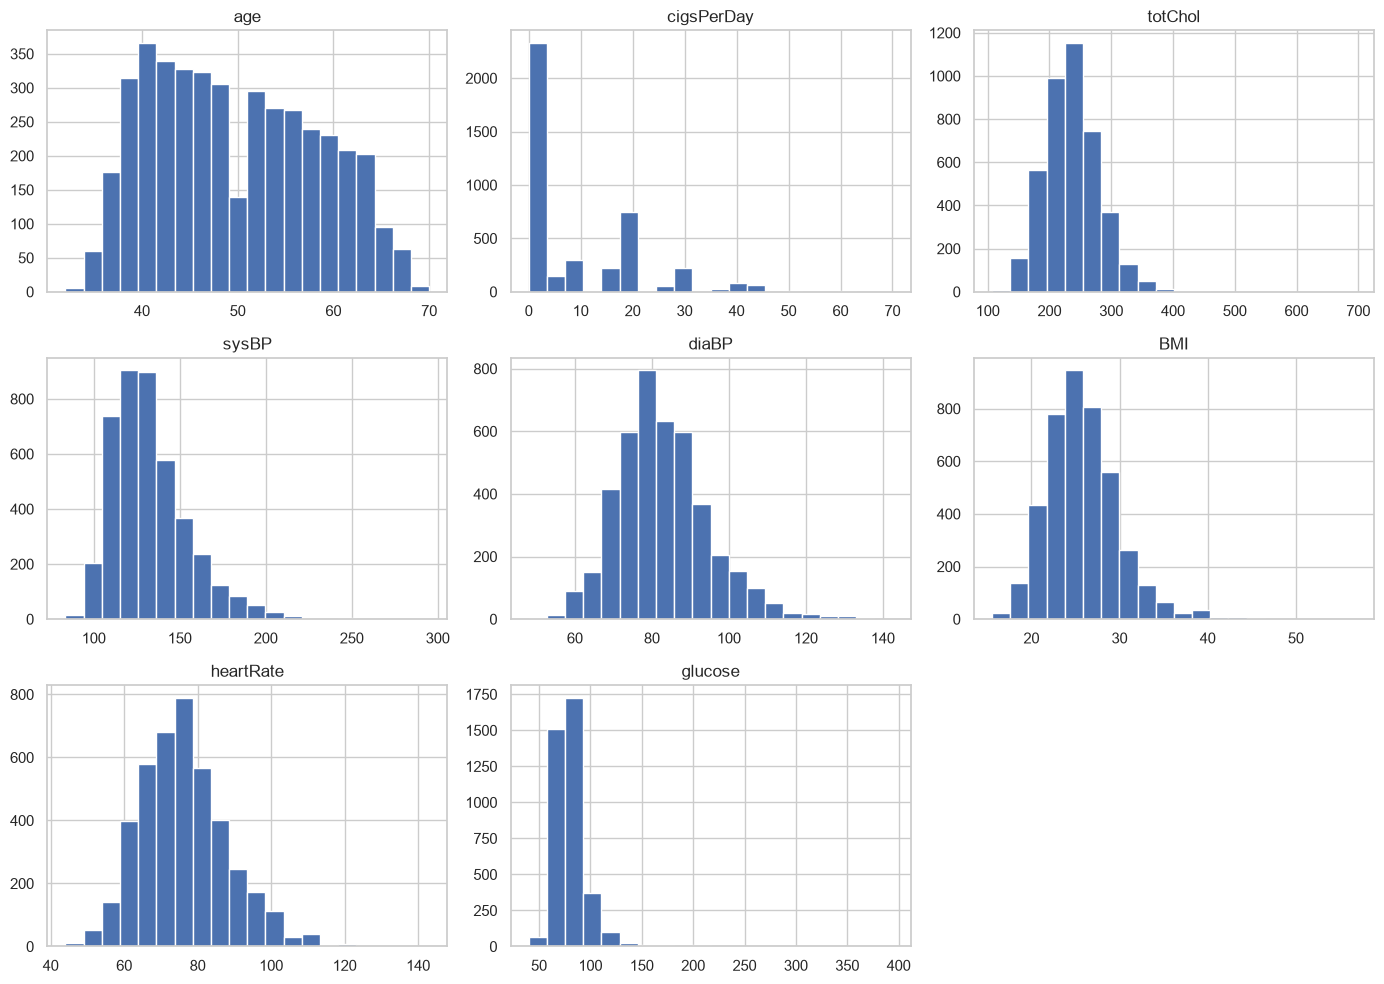

In [6]:
numeric_cols = ["age", "cigsPerDay", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()


## 6. Correlation heatmap

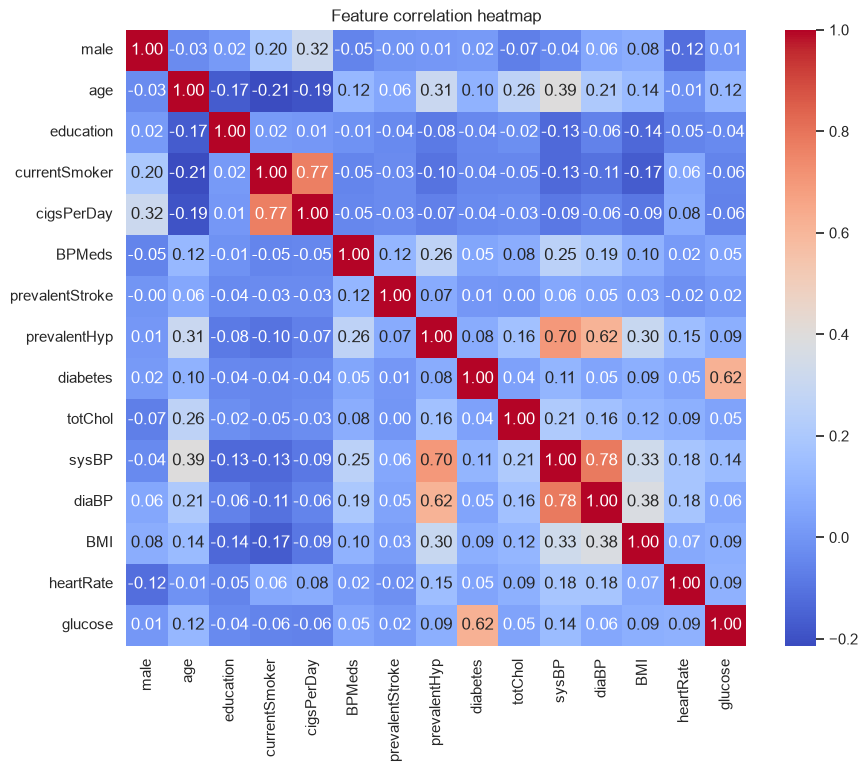

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop("TenYearCHD", axis=1).corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.show()


## 7. sysBP / diaBP by hypertension status
Sanity check — hypertensive patients should clearly show
higher blood pressure readings.

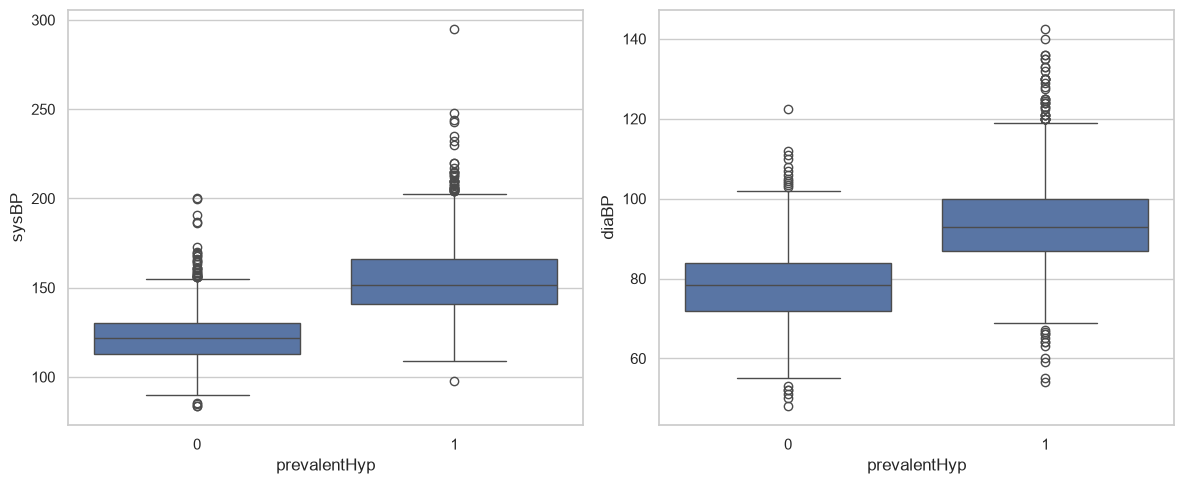

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="prevalentHyp", y="sysBP", data=df, ax=axes[0])
sns.boxplot(x="prevalentHyp", y="diaBP", data=df, ax=axes[1])
plt.tight_layout()
plt.show()


## Notes / takeaways
_Write down what you notice here before moving to preprocessing._